# 📦 Libraries Used in This Notebook

This notebook uses a combination of Python libraries for data manipulation, visualization, and machine learning.

---

## 🔢 Numerical Computing

### NumPy (`numpy`)
- Provides support for arrays and numerical operations
- Used for efficient mathematical computations

---

## 📊 Data Handling

### pandas (`pandas`)
- Used to load and manipulate structured data (e.g., CSV files)
- Data is stored in DataFrames for easy analysis and preprocessing

---

## 📈 Data Visualization

### Matplotlib (`matplotlib.pyplot`)
- Used for creating basic plots and visualizations

### Seaborn (`seaborn`)
- Built on top of Matplotlib
- Provides advanced and visually appealing statistical plots

---

## 🤖 Machine Learning (`scikit-learn`)

### 🔹 Model Selection

**`train_test_split`**
- Splits the dataset into training and testing sets
- Helps evaluate model performance on unseen data

**`cross_val_score`**
- Performs cross-validation
- Provides a more reliable estimate of model performance

### 🔹 SimpleImputer

- Why use SimpleImputer over fillna? It integrates directly into a Pipeline, ensuring the same imputation is applied consistently to both train and test sets.

### 🔹 Preprocessing & Pipeline

**`StandardScaler`**
- Scales features to have mean = 0 and standard deviation = 1
- Important for models sensitive to feature magnitude

**`Pipeline`**
- Combines preprocessing and modeling steps into a single workflow
- Ensures consistency and avoids data leakage

### 🔹 Model

**`LinearRegression`**
- A regression algorithm used to predict continuous values
- Models the relationship between features and target using a linear equation

---

## 🎯 Workflow Summary

**Load Data** → **Explore Data** → **Preprocess Data** → **Train Model** → **Evaluate Model**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [2]:
import os
os.listdir("/kaggle/input")

['competitions']

In [3]:
df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")


In [4]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# 🎯 Feature & Target Selection

## 📥 Input Features (`X`)

The following features were selected to predict house prices:

| Feature | Description |
|---|---|
| `GrLivArea` | Above-ground living area in square feet |
| `BedroomAbvGr` | Number of bedrooms above ground level |
| `FullBath` | Number of full bathrooms |

```python
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]
X = df[features]
```

---

## 🏷️ Target Variable (`y`)

**`SalePrice`** — The final sale price of the house in USD. This is the continuous value our model will learn to predict.

```python
y = df["SalePrice"]
```

---

## 🔍 Why These Features?

- **`GrLivArea`** — Living area is one of the strongest predictors of house price. Larger homes generally sell for more.
- **`BedroomAbvGr`** — Number of bedrooms directly impacts a home's market value and buyer appeal.
- **`FullBath`** — Full bathrooms are a key factor in pricing, especially in family homes.

---

## 📊 Shape Summary

| | Shape |
|---|---|
| `X` (features) | `(n_rows, 3)` |
| `y` (target) | `(n_rows,)` |

In [5]:
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]
X = df[features]
y = df["SalePrice"]

## 🔹 Train-Test Split

In machine learning, we divide the dataset into two parts: training data and testing data.

Training data is used to teach the model.
Testing data is used to evaluate how well the model performs on unseen data

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🔹 Machine Learning Pipeline
A Pipeline in machine learning is used to automate and organize multiple steps such as preprocessing and model training into a single workflow.

### Imputer (SimpleImputer)
→ Replaces missing values with the mean of each column
→ Prevents errors since most models cannot handle missing data
### Scaler (StandardScaler)
→ Standardizes features (mean = 0, standard deviation = 1)
→ Helps models perform better, especially when features have different scales
### Model (LinearRegression)
→ A simple algorithm that learns the relationship between input features and the target variable

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # handle missing values
    ("scaler", StandardScaler()),                  # scale features
    ("model", LinearRegression())                  # model
])


## 🔹 Model Training using Pipeline

We train the machine learning pipeline on the training data using the fit() method.

- The pipeline learns from X_train (features) and y_train (target)
- It sequentially applies all preprocessing steps (like imputation and        scaling)
- Finally, the model learns patterns from the processed data

In [8]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model', LinearRegression())])

## 🔹 Model Evaluation using Cross-Validation

We evaluate the model using cross-validation to get a reliable estimate of its performance.

### Explanation
- cross_val_score splits the training data into 5 folds (cv=5)
- The model is trained and validated 5 times, each time using a different     fold for validation
- This produces multiple performance scores instead of relying on a single    split
|
### Outputs
- CV Scores → Performance scores for each fold
- Mean Score → Average performance across all folds

In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline, X_train, y_train, cv=5)

print("CV Scores:", scores)
print("Mean Score:", scores.mean())

CV Scores: [0.66406311 0.42741015 0.49339831 0.53660567 0.65846166]
Mean Score: 0.5559877778228023


## 🔹 Making Predictions on Test Data

We use the trained pipeline to make predictions on the unseen test data.

### Explanation
- The pipeline takes X_test (unseen features) as input
- It applies the same preprocessing steps used during training
- The trained model then generates predictions

### Output
- y_pred → Predicted values for the test dataset

In [10]:
y_pred = pipeline.predict(X_test)

## 🔹 Model Evaluation using Mean Squared Error (MSE)

We evaluate the model’s prediction performance using Mean Squared Error.

### Explanation
- y_test → Actual (true) values
- y_pred → Predicted values from the model
- mean_squared_error computes the average of squared differences between      actual and predicted values

### What is MSE?
- Measures how far predictions are from actual values
- Penalizes larger errors more heavily (because of squaring)

In [11]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2806426667.247134


## 🔹 Root Mean Squared Error (RMSE)

- While MSE is useful, it is not in the same unit as the target variable.  
- RMSE is the square root of MSE and provides a more interpretable metric.

It represents the average prediction error in the same unit as house prices.


In [12]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 52975.71771337444


## 🔹 Baseline Model Comparison

To understand if our model is actually useful, we compare it with a simple baseline.

Baseline Strategy:
Predict the mean house price for all observations.

If our model does not outperform this baseline, it means the model is not learning meaningful patterns.


In [13]:
baseline = y_train.mean()
baseline_preds = [baseline] * len(y_test)

baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(baseline_mse)

print("Baseline RMSE:", baseline_rmse)


Baseline RMSE: 87619.03450611533


## 🔹 Model vs Baseline Comparison

We compare the RMSE of our trained model with the baseline model.

- If Model RMSE < Baseline RMSE → Model is useful ✅
- If Model RMSE ≈ Baseline RMSE → Model is weak ⚠️
- If Model RMSE > Baseline RMSE → Model is poor ❌


## 🔹 Model Improvement: Random Forest Regressor

Linear Regression assumes a linear relationship between features and target.
However, real-world data often contains complex, non-linear patterns.

We use Random Forest, an ensemble model, to capture these patterns.


## 🔹 Hyperparameter Tuning using GridSearchCV

Machine learning models have hyperparameters that control how they learn.

Instead of manually guessing these values, we use GridSearchCV to:
- Try multiple combinations of hyperparameters
- Evaluate each combination using cross-validation
- Select the best-performing model automatically

This helps improve model performance in a systematic and reliable way.


## 🔹 Create Pipeline for Tuning

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestRegressor(random_state=42))
])


## 🔹 Define Parameter Grid

In [15]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}


## 🔹 Apply GridSearchCV

In [16]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)


## 🔹 Train Grid Search

In [17]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [50, 100]},
             scoring='neg_mean_squared_error')

## 🔹  Best Parameters

In [18]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}


## 🔹 Evaluate Tuned Model

In [19]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Tuned Model RMSE:", rmse)


Tuned Model RMSE: 47374.85961501451


### “The baseline model achieved an RMSE of 87,619. 

### After applying hyperparameter tuning to a Random Forest Regressor, the RMSE decreased to 47,374, representing an improvement of approximately 46%. 

### This demonstrates the effectiveness of ensemble methods and hyperparameter optimization in reducing prediction error.”

## Linear Regression (Actual vs Predicted)

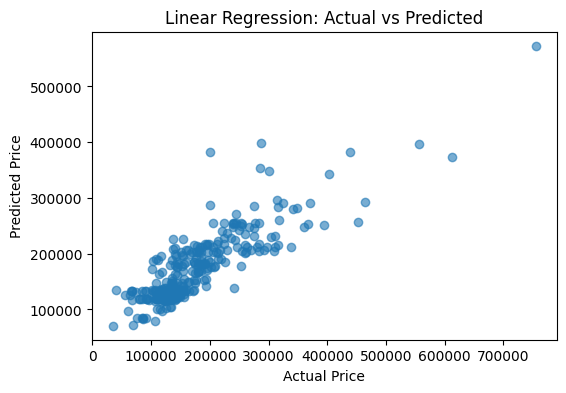

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


## Random Forest (Actual vs Predicted)

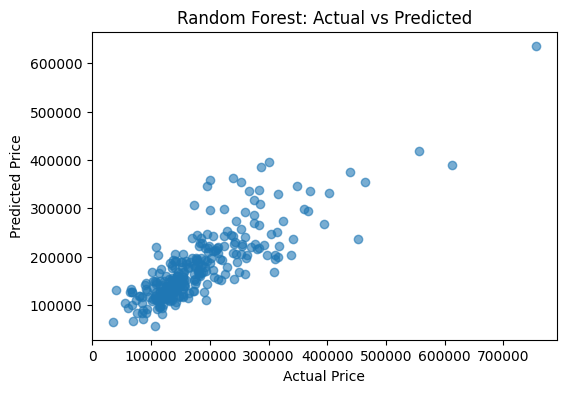

In [21]:
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()


## Side-by-side comparison

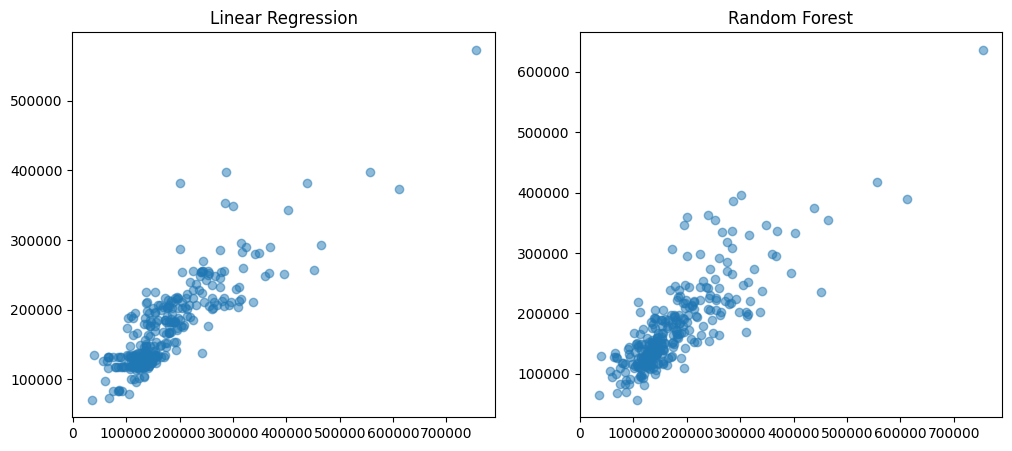

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title("Linear Regression")

plt.subplot(1,2,2)
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.title("Random Forest")

plt.show()


## Error comparison plot

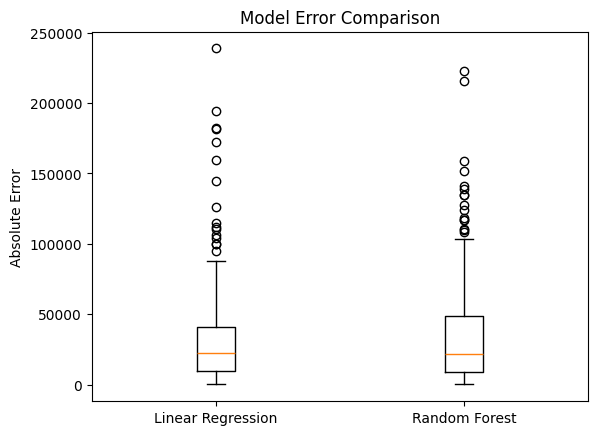

In [23]:
import warnings
warnings.filterwarnings("ignore")

errors = {
    "Linear Regression": np.sqrt((y_test - y_pred)**2),
    "Random Forest": np.sqrt((y_test - rf_pred)**2)
}

plt.boxplot(errors.values(), labels=errors.keys())
plt.title("Model Error Comparison")
plt.ylabel("Absolute Error")
plt.show()


## 🔹 Conclusion

In this project, we built a complete machine learning pipeline to predict house prices using regression models.

We started with Linear Regression as a baseline model. This helped establish a simple relationship between selected features and the target variable (SalePrice). The model was trained using a structured pipeline that included missing value handling (SimpleImputer) and feature scaling (StandardScaler). Its performance was evaluated using RMSE, which gave a clear measure of prediction error in actual house price units.

Next, we improved the approach by introducing a more powerful model, Random Forest Regressor. This model was optimized using GridSearchCV, which systematically tested different hyperparameter combinations using cross-validation. This ensured more reliable and generalizable performance compared to a single train-test split.

## From model comparison and evaluation:

Linear Regression provided a strong baseline but was limited in capturing complex patterns.
Random Forest performed better by capturing non-linear relationships in the data.

Visualization (Actual vs Predicted plots and residual analysis) further confirmed that the Random Forest model produced tighter predictions and smaller errors compared to Linear Regression.

## 🔹 Final Insight

This project demonstrates that while simple models are useful for baseline understanding, model tuning and algorithm selection significantly improve predictive performance. Techniques like pipelines, cross-validation, and GridSearchCV are essential for building robust and production-ready machine learning systems.